In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binned_statistic_2d
from sklearn import metrics

Reading the games' event data:

In [2]:
df_all = pd.read_json('events/events_England.json')
countries = ['Spain','Italy','Germany','France']
for i in countries:
    df = pd.read_json('events/events_'+i+'.json')
    df_all = pd.concat([df_all, df])

df_all.head()

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,Pass,1609,1H,2.758649,85,177959171
1,8,High pass,[{'id': 1801}],370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,Pass,1609,1H,4.946850,83,177959172
2,8,Head pass,[{'id': 1801}],3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,Pass,1609,1H,6.542188,82,177959173
3,8,Head pass,[{'id': 1801}],120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,Pass,1609,1H,8.143395,82,177959174
4,8,Simple pass,[{'id': 1801}],167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,Pass,1609,1H,10.302366,85,177959175


## Ball movements:
Spliting the pitch into a 16x12 grid for all passes, dribbles and shots. The target here is to find the shoot and move matrix, which explains the probability of choosing between shooting or moving (passing or dribbling) the ball.

### Calculating the probability of choosing to move the ball (pass or dribble) or to shoot from a certain position.

The case of shooting is examined first by checking the shots positions and creating a simplisting ExG model:

In [3]:
df_actions = df_all.copy()
df_actions['Pass'] =  df_all['eventName']=='Pass'
df_actions['Shot'] =  df_all['eventName']=='Shot'
df_actions['Dribble'] =  df_all['subEventName']=='Ground attacking duel'
df_actions['Succesfull'] = ((df_actions.tags.str[0].str['id']==1801) | (df_actions.tags.str[0].str['id']==703) | (df_actions.tags.str[0].str['id']==101))

mask = (df_actions['Pass']+df_actions['Shot']+df_actions['Dribble'])==1
df_actions = df_actions[mask]
df_actions.drop(columns=['tags','eventId','subEventName','eventName','subEventId'],inplace=True)
df_actions.head()


,playerId,positions,matchId,teamId,matchPeriod,eventSec,id,Pass,Shot,Dribble,Succesfull
0,25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",2499719,1609,1H,2.758649,177959171,True,False,False,True
1,370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",2499719,1609,1H,4.946850,177959172,True,False,False,True
2,3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",2499719,1609,1H,6.542188,177959173,True,False,False,True
3,120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",2499719,1609,1H,8.143395,177959174,True,False,False,True
4,167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",2499719,1609,1H,10.302366,177959175,True,False,False,True


In [4]:
x_edges = np.linspace(0, 100, 17)
y_edges = np.linspace(0, 100, 13)

df_shots = df_actions[df_actions['Shot']==1][['positions','Succesfull']]

Nof_Shots,_, _ = np.histogram2d(df_shots['positions'].str[0].str['x'],df_shots['positions'].str[0].str['y'],
                                bins=[x_edges, y_edges])


Nof_G_Shots , _, _, _ = binned_statistic_2d(df_shots['positions'].str[0].str['x'],df_shots['positions'].str[0].str['y'],df_shots['Succesfull'],statistic='sum',
                                bins=[x_edges, y_edges])

The probability of scoring from each position is calculated as as the division of goals to number of shots from every position of the grid. Due to the small number of shots from positions far from target and a few lucky shots from there the results of the above calculation can be misleading. A way to fix that is to assign an extremely small probability (close to zero) for position of the grid with less than 300 shots, as it can be seen below these positions have extremely low number of goals and shots.

In [5]:
Nof_Shots += 1
Ex_G = (Nof_G_Shots+0.00001)/(Nof_Shots)
Ex_G[Nof_Shots<300] = 0.00001

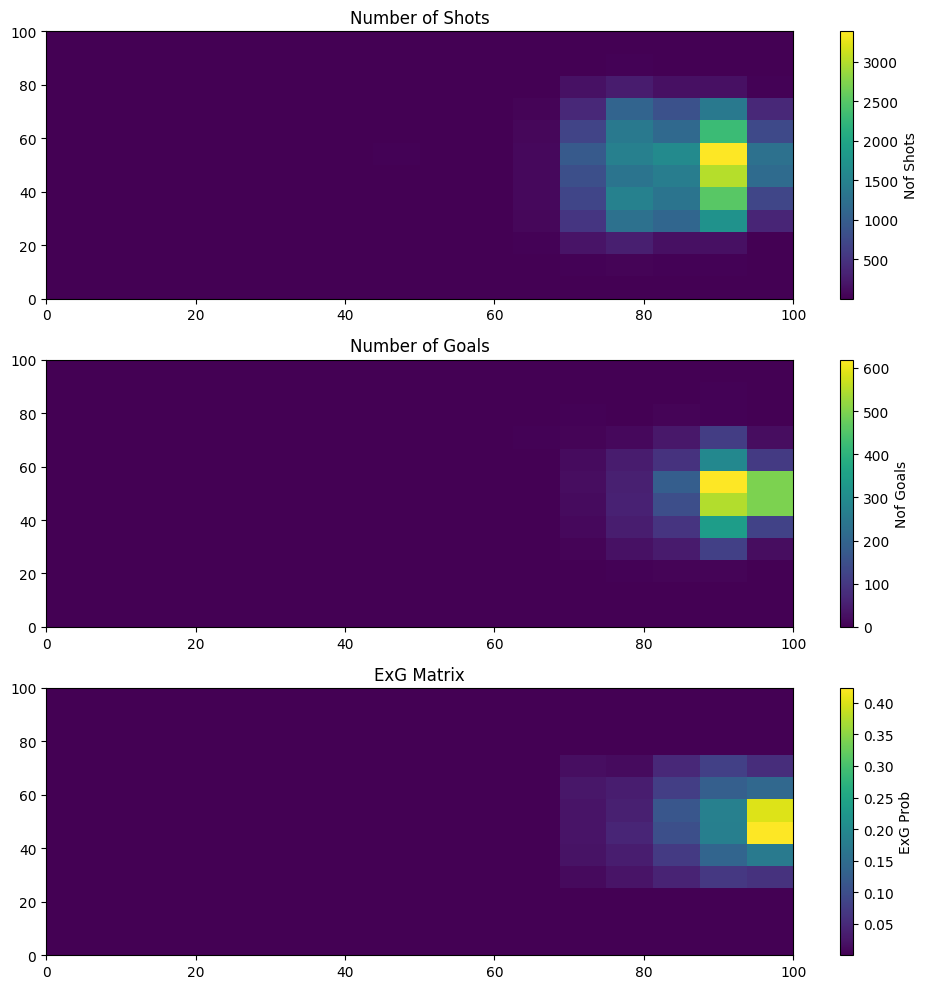

In [6]:
fig , ax = plt.subplots( 3,1,figsize=(10,10))

im0 = ax[0].pcolormesh(x_edges, y_edges, Nof_Shots.T)
fig.colorbar(im0, ax=ax[0],label="Nof Shots")
ax[0].set_title("Number of Shots")

im0 = ax[1].pcolormesh(x_edges, y_edges, Nof_G_Shots.T)
fig.colorbar(im0, ax=ax[1],label="Nof Goals")
ax[1].set_title("Number of Goals")


im0 = ax[2].pcolormesh(x_edges, y_edges, Ex_G.T)
fig.colorbar(im0, ax=ax[2],label="ExG Prob")
ax[2].set_title("ExG Matrix")

plt.tight_layout()

Similarly the same matrices are calculated for passes and dribbles. Some interesting results shows that dribbles are mainly tried at the sides of the pitch but they are very unsuccessful expect close to the teams' own area. Passes on the other hand are having extremely high success probability expect at areas close to the target with the majority of them happening close to the central area of the pitch.

In [7]:
df_dribble = df_actions[df_actions['Dribble']==1][['positions','Succesfull']]
df_pass = df_actions[df_actions['Pass']==1][['positions','Succesfull']]

Nof_Dribble,_, _ = np.histogram2d(df_dribble['positions'].str[0].str['x'],df_dribble['positions'].str[0].str['y'],
                                bins=[x_edges, y_edges])


Nof_S_Dribble , _, _, _ = binned_statistic_2d(df_dribble['positions'].str[0].str['x'],df_dribble['positions'].str[0].str['y'],df_dribble['Succesfull'],statistic='sum',
                                bins=[x_edges, y_edges])

Nof_Pass,_, _ = np.histogram2d(df_pass['positions'].str[0].str['x'],df_pass['positions'].str[0].str['y'],
                                bins=[x_edges, y_edges])


Nof_S_Pass , _, _, _ = binned_statistic_2d(df_pass['positions'].str[0].str['x'],df_pass['positions'].str[0].str['y'],df_pass['Succesfull'],statistic='sum',
                                bins=[x_edges, y_edges])

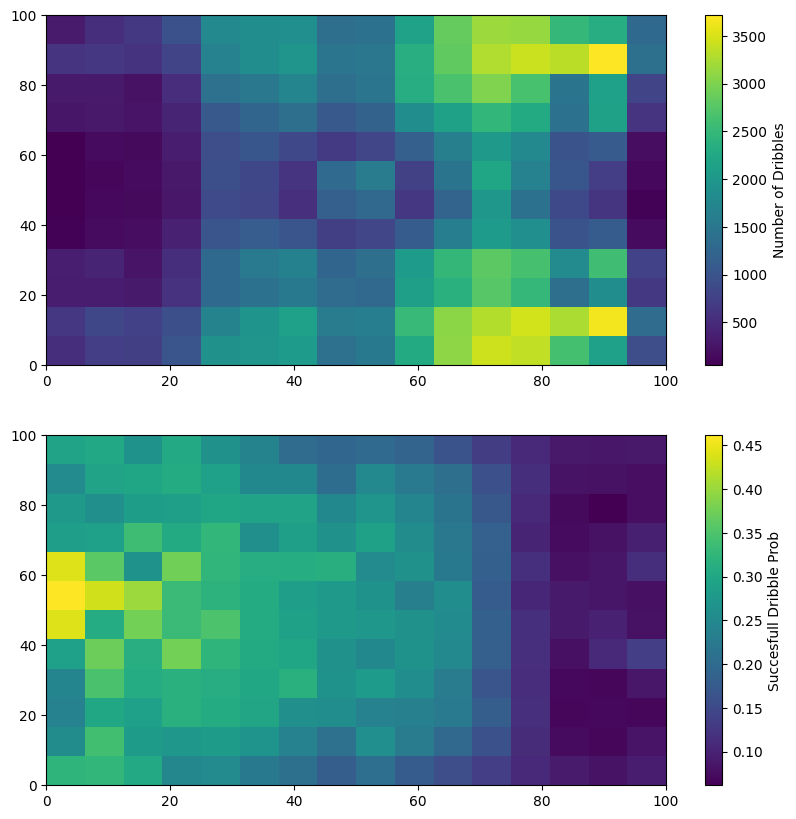

In [8]:
fig , ax = plt.subplots( 2,1,figsize=(10,10))

im0 = ax[0].pcolormesh(x_edges, y_edges, Nof_Dribble.T)
fig.colorbar(im0, ax=ax[0],label="Number of Dribbles")

im0 = ax[1].pcolormesh(x_edges, y_edges, (Nof_S_Dribble/Nof_Dribble).T)
fig.colorbar(im0, ax=ax[1],label="Succesfull Dribble Prob")


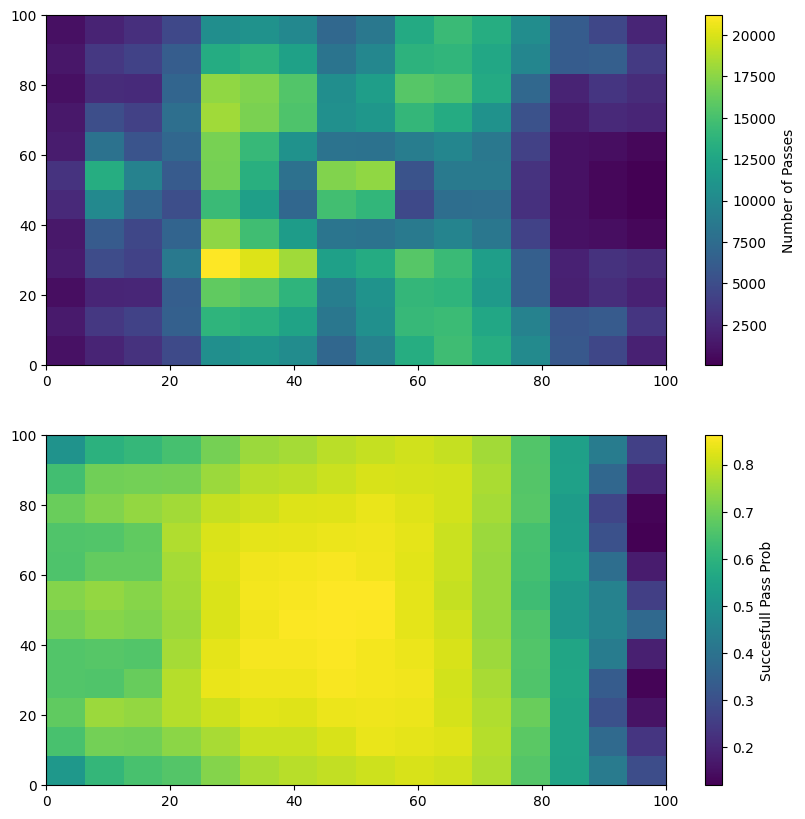

In [9]:
fig , ax = plt.subplots( 2,1,figsize=(10,10))

im0 = ax[0].pcolormesh(x_edges, y_edges, Nof_Pass.T)
fig.colorbar(im0, ax=ax[0],label="Number of Passes")

im0 = ax[1].pcolormesh(x_edges, y_edges, (Nof_S_Pass/Nof_Pass).T)
fig.colorbar(im0, ax=ax[1],label="Succesfull Pass Prob")


### Move Probability Matrix:
Below the Move Probability Matrix is calculated as the division of number of passes and dribbles to total actions in every position of the grid. As it can be seen at the majority of the pitch moving the ball is close to 100% the choosen decision while close to the target is getting lower and lower reaching values very close to zero, meaning shooting is the taken decision.

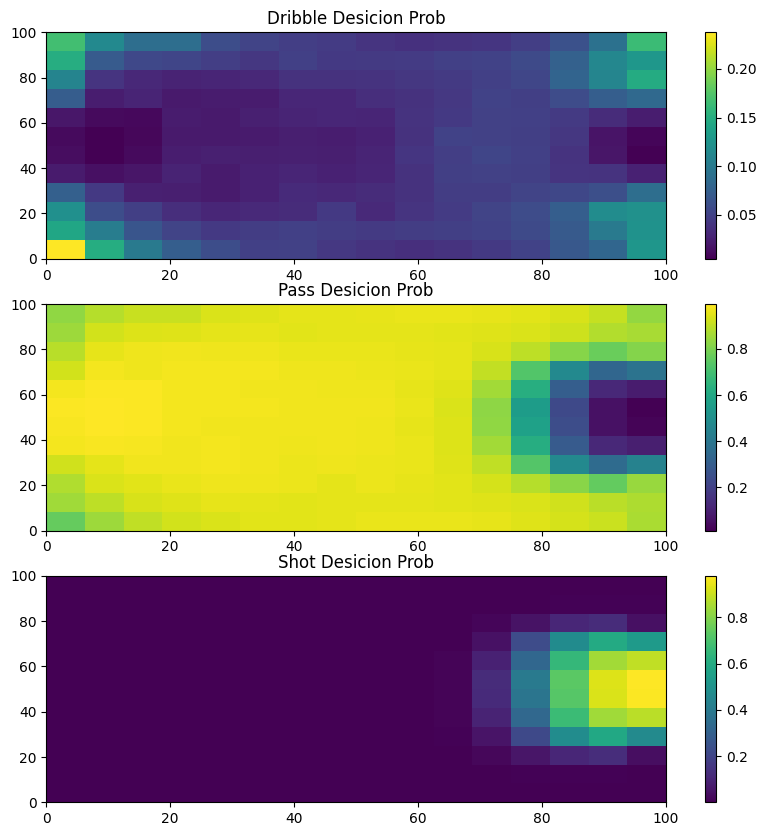

In [10]:
Shot_Prob = Nof_Shots/(Nof_Shots+Nof_S_Dribble+Nof_S_Pass)
Pass_Prob = Nof_S_Pass/(Nof_Shots+Nof_S_Dribble+Nof_S_Pass)
Dribble_Prob = Nof_S_Dribble/(Nof_Shots+Nof_S_Dribble+Nof_S_Pass)
Move_Prob = 1-Shot_Prob

fig , ax = plt.subplots( 3,1,figsize=(10,10))

im0 = ax[0].pcolormesh(x_edges, y_edges, Dribble_Prob.T)
fig.colorbar(im0, ax=ax[0])
ax[0].set_title("Dribble Desicion Prob")

im0 = ax[1].pcolormesh(x_edges, y_edges, Pass_Prob.T)
fig.colorbar(im0, ax=ax[1])
ax[1].set_title("Pass Desicion Prob")

im0 = ax[2].pcolormesh(x_edges, y_edges, Shot_Prob.T)
fig.colorbar(im0, ax=ax[2])
ax[2].set_title("Shot Desicion Prob")
plt.show()

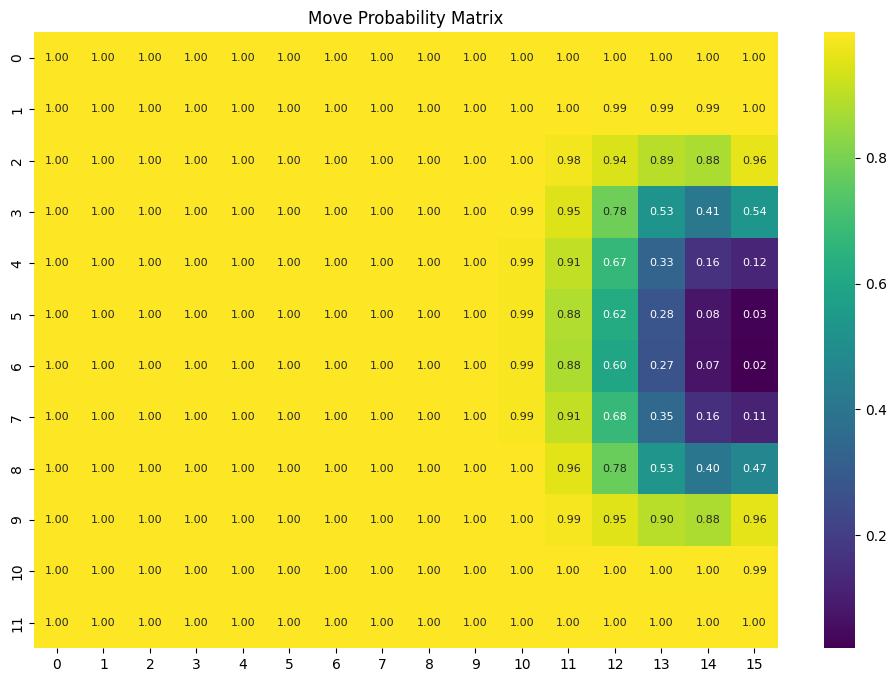

In [11]:
import seaborn as sns

plt.figure(figsize=(12,8))

plt.title("Move Probability Matrix")
sns.heatmap(
    Move_Prob.T,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    annot_kws={"size": 8}
)

plt.show()

## Calculation of Expected Threat (xT):

The Expected Threat is a metric for measuring the creation of chances for actions before and further away timewise from a shot. The ExG models describe the ending action of a chain of actions that lead to a shot, which makes it biased to attacking players who are positioned closer to the target. But what about actions that moved the ball to dangerous areas before a high ExG shot took place? The xT model adds value to players who move the ball from less dangerous to more dangerous areas with the exact value assigned to each action being the threat difference between the starting and ending position of the ball.

#### Transition Matrix:
Given that the pitch is splitted in a 16x12 matrix, the transition matrix of all points of the grid can be calculated given all the move actions' starting and ending positions. The transition matrix includes the probability of the ball moving from the grid's point (i,j) to (k,l):
 $$ T_{(i,j)\rightarrow(k,l)} $$

In [12]:
df_move = df_actions[df_actions['Succesfull']==1]


nx, ny = 16, 12
pass_start_x = df_move['positions'].str[0].str['x']
pass_end_x = df_move['positions'].str[1].str['x']
pass_start_y =df_move['positions'].str[0].str['y']
pass_end_y = df_move['positions'].str[1].str['y']


x1 = np.digitize(pass_start_x, x_edges) - 1
y1 = np.digitize(pass_start_y, y_edges) - 1

x2 = np.digitize(pass_end_x, x_edges) - 1
y2 = np.digitize(pass_end_y, y_edges) - 1

x1 = np.clip(x1, 0, nx-1)
y1 = np.clip(y1, 0, ny-1)
x2 = np.clip(x2, 0, nx-1)
y2 = np.clip(y2, 0, ny-1)

Transition_Matrix = np.zeros((nx, ny, nx, ny))

np.add.at(Transition_Matrix, (x1, y1, x2, y2), 1)

for i in range(0,len(x_edges)-1):
  for j in range(0,len(y_edges)-1):
    Transition_Matrix[i,j,:,:] = Transition_Matrix[i,j,:,:]/np.sum(Transition_Matrix[i,j,:,:])

As it can be seen below the transition matrix's results are reasonable with positions close to the starting point being more probable for being the ending points.

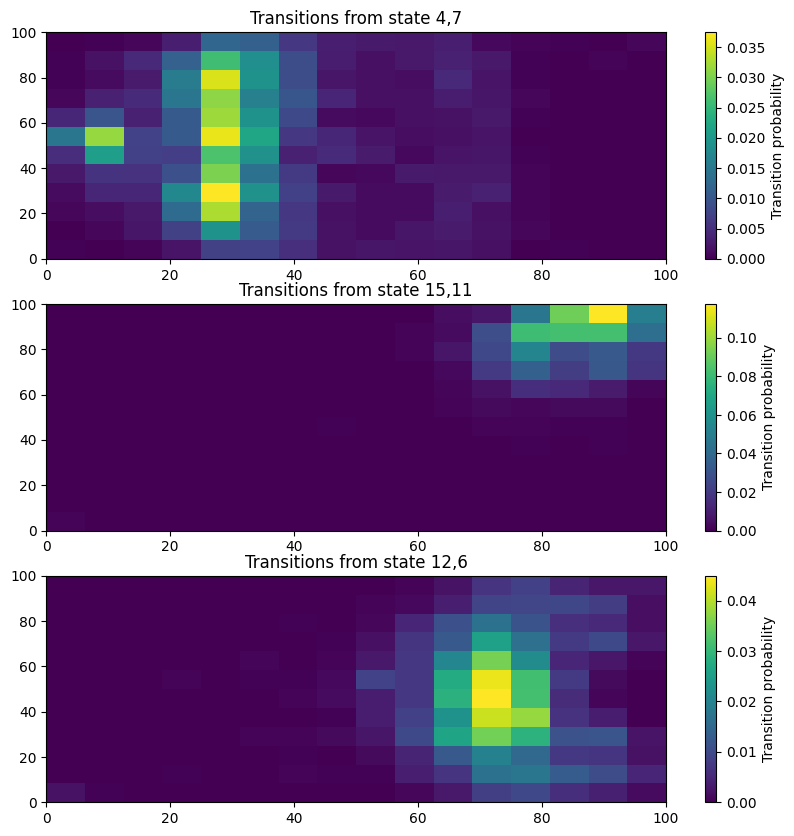

In [13]:
fig , ax = plt.subplots( 3,1,figsize=(10,10))

im0 = ax[0].pcolormesh(x_edges, y_edges, Transition_Matrix[3,6].T)
fig.colorbar(im0, ax=ax[0],label="Transition probability")
ax[0].set_title(f"Transitions from state 4,7")

im0 = ax[1].pcolormesh(x_edges, y_edges, Transition_Matrix[14,10].T)
fig.colorbar(im0, ax=ax[1],label="Transition probability")
ax[1].set_title(f"Transitions from state 15,11")

im0 = ax[2].pcolormesh(x_edges, y_edges, Transition_Matrix[11,5].T)
fig.colorbar(im0, ax=ax[2],label="Transition probability")
ax[2].set_title(f"Transitions from state 12,6")
plt.show()

### Calculating the xT matrix:
For the xT matrix 5 consecutive actions are taken into consideration since further number of actions has very small effect. The way for calculating the xT in each point in the grid is recursively by updating the xT matrix by an additional action in the past and adding it to the xT part given by the shooting option. As initial value of the xT the ExG matrix is used since it is equivalent with one action to only be posible to happen:

$$
xT(i,j)_{0} = ExG(i,j)
$$

$$
xT(i,j) = P_{\text{shot}}(i,j)\cdot ExG(i,j) + P_{\text{move}}(i,j) \cdot \sum_{k,l} \cdot T_{(i,j)\rightarrow(k,l)}\cdot xT(k,l)
$$

In [14]:
xT = Ex_G
iter = 5
for it in range(iter):
    new_xT = np.zeros_like(xT)

    for i in range(nx):
        for j in range(ny):
            new_xT[i,j] = Shot_Prob[i,j]*Ex_G[i,j]+Move_Prob[i,j]*np.sum(
                Transition_Matrix[i,j,:,:] * xT
            )

    xT = new_xT


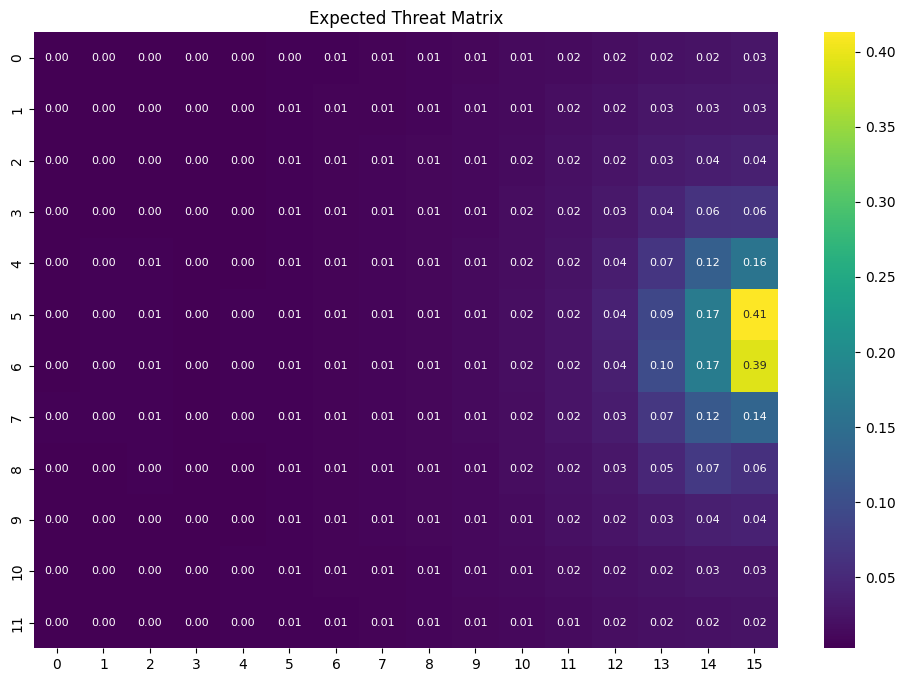

In [15]:
plt.figure(figsize=(12,8))

plt.title("Expected Threat Matrix")
sns.heatmap(
    xT.T,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    annot_kws={"size": 8}
)

plt.show()

In [16]:
np.save('xT.npy', xT)

## Results:
The xT of each player, team and League can be calculated given the xT matrix now, the most productive players and teams can be shown.

Given the xT matrix the positive xT of each ball move can be assigned to the whole dataset:

In [17]:
x_len_ed = x_edges[1]-x_edges[0]
y_len_ed = y_edges[1]-y_edges[0]

df_succ = df_actions[(df_actions['Shot']!=1) & (df_actions['Succesfull']==1)][['playerId','positions','teamId']]

pass_start_x = df_succ['positions'].str[0].str['x']
pass_end_x = df_succ['positions'].str[1].str['x']
pass_start_y =df_succ['positions'].str[0].str['y']
pass_end_y = df_succ['positions'].str[1].str['y']


In [18]:
x_start_id = (pass_start_x//x_len_ed).astype(int)
y_start_id = (pass_start_y//y_len_ed).astype(int)
x_end_id = (pass_end_x//x_len_ed).astype(int)
y_end_id = (pass_end_y//y_len_ed).astype(int)

x_start_id = np.clip(x_start_id,0, 15)
y_start_id = np.clip(y_start_id,0, 11)
x_end_id = np.clip(x_end_id,0, 15)
y_end_id = np.clip(y_end_id,0, 11)

df_succ['xT'] = xT[x_end_id,y_end_id]-xT[x_start_id,y_start_id]

We can calculate similarly the negative xT for every action of losing the ball, given that the position value of the ball gain for the opponent based on the xT of the other team:

In [19]:
df_unsucc = df_actions[(df_actions['Shot']!=1) & (df_actions['Succesfull']==0)][['playerId','positions','teamId']]
pass_end_x = df_unsucc['positions'].str[1].str['x']
pass_end_y = df_unsucc['positions'].str[1].str['y']

x_end_id = (pass_end_x//x_len_ed).astype(int)
y_end_id = (pass_end_y//y_len_ed).astype(int)
x_end_id = np.clip(x_end_id,0, 15)
y_end_id = np.clip(y_end_id,0, 11)

df_unsucc['Neg_xT'] = -xT[15-x_end_id,11-y_end_id]
mask_index = df_unsucc[(pass_end_x==100)*(pass_end_y==100)].index
df_unsucc.loc[mask_index,'Neg_xT'] = 0

Loading the players and team data:

In [20]:
df_players = pd.read_json('players.json')
df_players = df_players.drop(['passportArea', 'weight', 'middleName', 'birthDate', 'birthArea', 'firstName','foot','height',
                              'lastName','currentNationalTeamId','currentTeamId'], axis=1)

df_players = df_players.rename(columns={ 'wyId': 'playerId'})
roles = []
for i in range(0,len(df_players)):
    roles.append(df_players["role"][i]['code2'])

df_players['role'] = roles
df_players = df_players[df_players['role']!='GK']
df_players.head()

,role,playerId,shortName
1,DF,393228,M. Sarr
3,MD,32793,A. N'Diaye
4,DF,393247,I. Konat\u00e9
6,DF,36,T. Alderweireld
7,DF,48,J. Vertonghen


Calculating the xT for all players and their negative xT:

In [21]:
merged_1 = pd.merge(df_succ, df_players, on="playerId")
result_pl_1 = (
    merged_1.groupby("shortName", as_index=False)["xT"]
      .sum()
)

merged_2 = pd.merge(df_unsucc, df_players, on="playerId")
result_pl_2 = (
    merged_2.groupby("shortName", as_index=False)["Neg_xT"]
      .sum()
)

result_pl = pd.merge(result_pl_1, result_pl_2, on="shortName")
result_pl.sort_values("xT", ascending=False,inplace = True)
result_pl.head(20)

,shortName,xT,Neg_xT
1579,Marcelo,9.731444,-9.693284
1301,L. Messi,8.050488,-6.231109
1199,K. Koulibaly,6.999865,-4.369530
749,F\u00e0bregas,6.982983,-3.719197
1184,K. De Bruyne,6.623650,-5.815548
1254,L. Bonucci,6.176660,-3.845370
835,G. Xhaka,6.110877,-4.855649
559,Dani Parejo,6.046889,-5.900545
1567,M. \u00d6zil,6.022179,-3.489073
2307,\u00c9. Banega,5.896548,-5.579106


In [22]:
total_actions = (
    merged_1.groupby("shortName", as_index=False)["xT"]
      .count())

total_actions = total_actions.rename(columns={'xT': 'No_Actions'})
total_actions = pd.merge(total_actions, result_pl_1, on="shortName")
total_actions.sort_values("xT",inplace=True,ascending=False)
total_actions.head(10)

,shortName,No_Actions,xT
1594,Marcelo,3066,9.731444
1311,L. Messi,1454,8.050488
1208,K. Koulibaly,2592,6.999865
755,F\u00e0bregas,1635,6.982983
1193,K. De Bruyne,2062,6.623650
1264,L. Bonucci,1634,6.176660
841,G. Xhaka,2569,6.110877
563,Dani Parejo,1856,6.046889
1582,M. \u00d6zil,1500,6.022179
2327,\u00c9. Banega,1762,5.896548


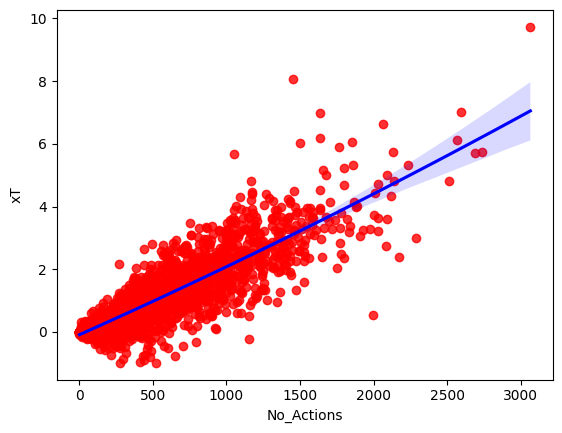

In [23]:
sns.regplot(
    data=total_actions,
    x="No_Actions",
    y="xT",
    order=2.,
    scatter_kws={"color": "red"},
    line_kws={"color": "blue"}
)

plt.show()

#### Teams and Leagues:

Loading teams' data:

In [24]:
df_teams = pd.read_json('teams.json')
df_teams = df_teams.drop(['city', 'officialName', 'type'], axis=1)
df_teams = df_teams.rename(columns={'wyId': 'teamId','name': 'team_name','area':'country'})

df_teams['country'] = df_teams['country'].str['name']
df_teams.loc[df_teams['country']=='Wales','country'] = 'England'
df_teams.loc[df_teams['country']=='Monaco','country'] = 'France'
df_teams.head()

,team_name,teamId,country
0,Newcastle United,1613,England
1,Celta de Vigo,692,Spain
2,Espanyol,691,Spain
3,Deportivo Alav\u00e9s,696,Spain
4,Levante,695,Spain


In [25]:
merged = pd.merge(df_succ, df_teams, on="teamId")
merged.head()

,playerId,positions,teamId,xT,team_name,country
0,25413,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",1609,-0.003521,Arsenal,England
1,370224,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",1609,0.005710,Arsenal,England
2,3319,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",1609,-0.004611,Arsenal,England
3,120339,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",1609,0.000505,Arsenal,England
4,167145,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",1609,0.010400,Arsenal,England


Below the teams with the highest xT produced is shown, with Barcelona being clearly the best and Man City, Liverpool, Arsenal and Real Madrid to follow closely:

In [26]:
result = (
    merged.groupby("team_name", as_index=False)["xT"]
      .sum()
      .sort_values("xT", ascending=False)
)

result.head(10)

,team_name,xT
8,Barcelona,42.808581
3,Arsenal,42.248254
56,Manchester City,41.004381
53,Liverpool,40.480319
68,PSG,38.775924
71,Real Madrid,38.738062
63,Napoli,37.422089
4,Atalanta,36.867618
21,Chelsea,36.580896
87,Tottenham Hotspur,33.956888


Below the xT produced in total for each League is presented with Premier League to be on top amd Italy and France following. The worst League in terms of xT is by far the Bundensliga:

In [27]:
result = (
    merged.groupby("country", as_index=False)["xT"]
      .sum()
      .sort_values("xT", ascending=False)
)

result.head(20)

,country,xT
0,England,544.929314
3,Italy,535.835450
1,France,516.994085
4,Spain,493.929040
2,Germany,450.347235


## Match Momentum:

With the xT at different times in a game a deeper understanding on what happened in a match is possible to be found beyond the limits of just using the ExG metric. A way to extract information by the xT would be by just comparing the cumulative distribution of each team's xT but this can be misleading due to teams with more possesions (and thus passes) create much more xT with small values when they have the ball compared to a team playing with mainly very dangerous counter attacks. For solving this problem a different metric is used, the match mommentum. The goal of this metric is to capture which team was pressuring more for a goal at each minute and how much was that pressure. This metric needs to capture what the game "looked like" for a viewer so it has to be continous and without large fluctuations from minute to minute.

Due to extreme values of xT that can be created by a great chance the discussed format needs an adjustment since the mommentum graph would be fluctuating in a very wide range, the correction needed is to clip all the xT values to [0,0.10]. Also, the mommentum values of previous minutes are accounted as well since the mommentum has to shift in a continous way. The last 4 minutes are taken into consideration with some exponential time decay weights $w_{i}$ since the most recent minutes should have a bigger impact. The time decay constant is fixed at 0.30 but in general it can be calculated by parameter optimazation while using mommentum for predicting ExG or which team is going to score within a certain timespan.

The formula calculating the match momment is given by:

$$ \mu_{xT} = \sum w_{i} \cdot xT_{home max, i} - \sum w_{i} \cdot xT_{away max, i} $$
$$ w_{i} = e^{-c_{decay} \cdot (t_{last}-t_{i})} , t_{last} - t_{i} < 5$$

You can find a similar article for football match mommentum here:
https://medium.com/@aleks-kapich/how-to-calculate-and-plot-football-match-momentum-using-event-data-1ca3a9ac4a39

Let's isolate the passes and carries actions from the previous actions dataframe and calculate the xT of each action for a given game (with matchId being 2499719). The time variable for the momentum is minutes while the xT values are clipped at [0,0.1] as explained before.

In [298]:
df_match_mommentum = df_actions[(df_actions['Shot'] == False) & (df_actions['Succesfull'] == True) & (df_actions['matchId'] == 2499719)][['eventSec','matchPeriod','positions','teamId']]

x_len_ed = x_edges[1]-x_edges[0]
y_len_ed = y_edges[1]-y_edges[0]

pass_start_x = df_match_mommentum['positions'].str[0].str['x']
pass_end_x = df_match_mommentum['positions'].str[1].str['x']
pass_start_y =df_match_mommentum['positions'].str[0].str['y']
pass_end_y = df_match_mommentum['positions'].str[1].str['y']

x_start_id = (pass_start_x//x_len_ed).astype(int)
y_start_id = (pass_start_y//y_len_ed).astype(int)
x_end_id = (pass_end_x//x_len_ed).astype(int)
y_end_id = (pass_end_y//y_len_ed).astype(int)

x_start_id = np.clip(x_start_id,0, 15)
y_start_id = np.clip(y_start_id,0, 11)
x_end_id = np.clip(x_end_id,0, 15)
y_end_id = np.clip(y_end_id,0, 11)

df_match_mommentum['xT'] = xT[x_end_id,y_end_id]-xT[x_start_id,y_start_id]

df_match_mommentum['minute'] = df_match_mommentum['eventSec']//60
mask_HT = (df_match_mommentum['minute']>45)*(df_match_mommentum['matchPeriod']=='1H')
df_match_mommentum.loc[mask_HT,'minute'] = 45 + 0.1*df_match_mommentum[mask_HT]['minute']%10 
df_match_mommentum.loc[df_match_mommentum['matchPeriod'] == '2H','minute'] += 45

df_match_mommentum['xT_clipped'] = np.clip(df_match_mommentum['xT'], 0, 0.1)

df_match_mommentum.head()

,eventSec,matchPeriod,positions,teamId,xT,minute,xT_clipped
0,2.758649,1H,"[{'y': 49, 'x': 49}, {'y': 78, 'x': 31}]",1609,-0.003521,0.0,0.000000
1,4.946850,1H,"[{'y': 78, 'x': 31}, {'y': 75, 'x': 51}]",1609,0.005710,0.0,0.005710
2,6.542188,1H,"[{'y': 75, 'x': 51}, {'y': 71, 'x': 35}]",1609,-0.004611,0.0,0.000000
3,8.143395,1H,"[{'y': 71, 'x': 35}, {'y': 95, 'x': 41}]",1609,0.000505,0.0,0.000505
4,10.302366,1H,"[{'y': 95, 'x': 41}, {'y': 88, 'x': 72}]",1609,0.010400,0.0,0.010400


From the above matrix only the maximum value of xT for each at each monute is needed:

In [299]:
max_xT_per_minute = df_match_mommentum.groupby(['teamId', 'minute'])['xT_clipped'].max().reset_index()
max_xT_per_minute.head()

,teamId,minute,xT_clipped
0,1609,0.0,0.016117
1,1609,1.0,0.011823
2,1609,2.0,0.000000
3,1609,3.0,0.002073
4,1609,5.0,0.001176


The minutes of the goals of this game are extracted from the data:

In [300]:
goals = df_all[(df_all['matchId']==2499719)*(df_all['eventName']=='Shot')]
goals = goals[(goals.tags.str[0].str['id']==101)][['teamId','matchPeriod','eventSec']]
goals['minutes'] = goals['eventSec']//60 + 45*(goals['matchPeriod']=='2H')

mask_HT = (goals['minutes']>45)*(goals['matchPeriod']=='1H')
goals.loc[mask_HT,'minutes'] = 45 + 0.1*goals[mask_HT]['minutes']%10 

goals

,teamId,matchPeriod,eventSec,minutes
46,1609,1H,94.595788,1.0
91,1631,1H,254.745027,4.0
554,1631,1H,1710.855093,28.0
898,1609,1H,2815.900791,49.6
1107,1631,2H,634.312236,55.0
1570,1609,2H,2231.119656,82.0
1613,1609,2H,2374.620655,84.0


The momentum of the game can be calculated now given the max xT at each minute of each time:

In [301]:
minutes = sorted(max_xT_per_minute['minute'].unique())
window_size = 5
c_decay = 0.30
momentum = []

for current_minute in minutes:
    k=0
    weighted_sum_all = 0
    for team in max_xT_per_minute['teamId'].unique():
        recent_xT_values = max_xT_per_minute[(max_xT_per_minute['teamId'] == team) & 
                                            (max_xT_per_minute['minute'] <= current_minute) & 
                                            (max_xT_per_minute['minute'] > current_minute - window_size)]
        
        weights = np.exp(-c_decay * (current_minute - recent_xT_values['minute'].values))
        weighted_sum = np.sum(weights * recent_xT_values['xT_clipped'].values)
        weighted_sum_all += weighted_sum*(-1)**k
        k += 1
        
    momentum.append(weighted_sum_all)

Now the mommentum at each minute can be graphed smoothed by a Gaussian filter with $\sigma = 2$ ,showing the values of each minute with the minutes of goals scored  for the game Arsenal against Leicester:

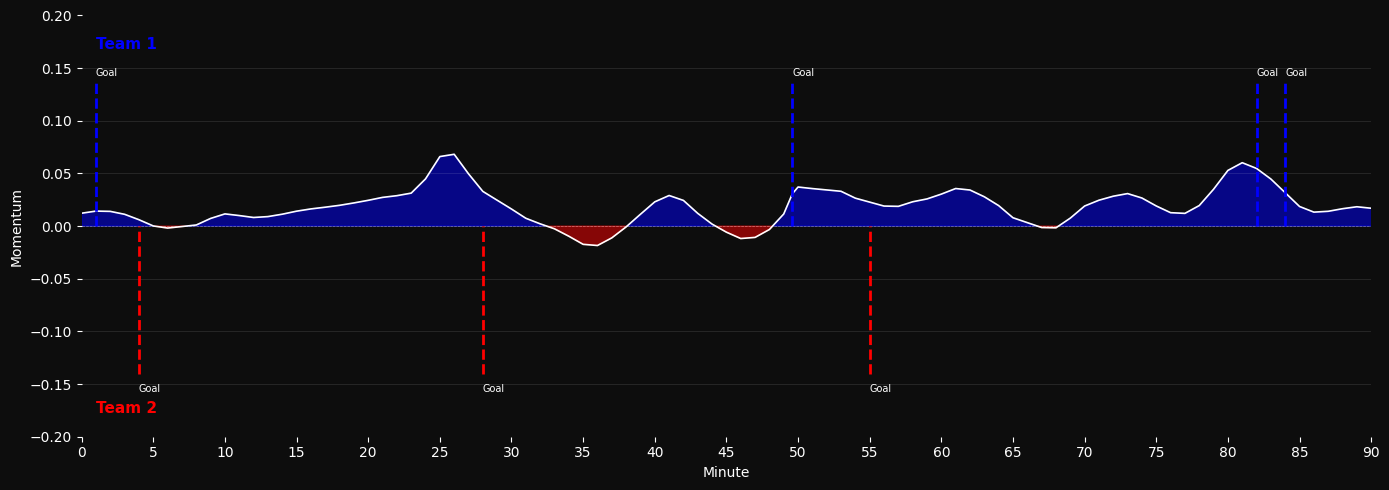

In [305]:
from scipy.ndimage import gaussian_filter1d
smoothed_momentum = gaussian_filter1d(momentum, sigma=1)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

ax.plot(minutes, smoothed_momentum, color='white', linewidth=1.2)
ax.axhline(0, color='white', linestyle='--', linewidth=0.5, alpha=0.4)
ax.fill_between(minutes, smoothed_momentum, where=(smoothed_momentum > 0), color='blue', alpha=0.5, interpolate=True)
ax.fill_between(minutes, smoothed_momentum, where=(smoothed_momentum < 0), color='red', alpha=0.5, interpolate=True)
ax.set_ylim(-0.2, 0.2)

for minute in goals[goals['teamId'] ==goals['teamId'].unique()[0]]['minutes']:
    ax.axvline(minute, color='blue', linewidth=2, ymin=0.5, ymax=0.85, linestyle='--')
    ax.text(minute, 0.15, 'Goal', color='white', fontsize=7, va='top')

for minute in goals[goals['teamId'] ==goals['teamId'].unique()[1]]['minutes']:
    ax.axvline(minute, color='red', linewidth=2, ymin=0.15, ymax=0.5, linestyle='--')
    ax.text(minute, -0.15, 'Goal', color='white', fontsize=7, va='top')

ax.set_xlim(0, 90)
ax.set_xticks(range(0, 91, 5))
ax.tick_params(colors='white')
ax.set_xlabel('Minute', color='white')
ax.set_ylabel('Momentum', color='white')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis='y', alpha=0.1, color='white')
ax.text(1,  0.18, 'Team 1', color='blue', fontsize=11, fontweight='bold', va='top')
ax.text(1, -0.18, 'Team 2', color='red',  fontsize=11, fontweight='bold', va='bottom')

plt.tight_layout()